## test new histograms locally

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate
import mplhep as hep
from helpers import *

In [2]:
# vr = "28"
nfiles = 3
sig2mu = [
    # "2Mu2E_500GeV_0p25GeV_4p0mm", #changing MZd
    # "2Mu2E_500GeV_1p2GeV_19p0mm",
     "2Mu2E_800GeV_5p0GeV_50p0mm",    
]

sig4mu = [
    "4Mu_500GeV_0p25GeV_0p004mm",
    "4Mu_500GeV_1p2GeV_19p0mm",
    "4Mu_500GeV_5p0GeV_80p0mm",
]

channels = [
    "baseNoLj",
    "base_ljObjCut",
    "ljsource_cuts",
]

ch1 = channels[0] # base
ch2 = channels[1] # base 2
ch3 = channels[2]

In [3]:
runner = processor.Runner(
    executor=processor.FuturesExecutor(),                # for testing locally
    # executor=processor.IterativeExecutor(),            # for testing locally
    schema = llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True,
)

p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"],
    unweighted_hist=True, verbose=False
)

In [4]:
# process 2mu2e
fileset2mu = utilities.make_fileset(sig2mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_2mu2e_v10.yaml")
out2mu = runner.run(fileset2mu, treename="Events", processor_instance=p)
out2mu = out2mu["out"]
# coffea.util.save(out2mu, "outputs/bkg_" + vr + "_2mu.coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


2Mu2E_800GeV_5p0GeV_50p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


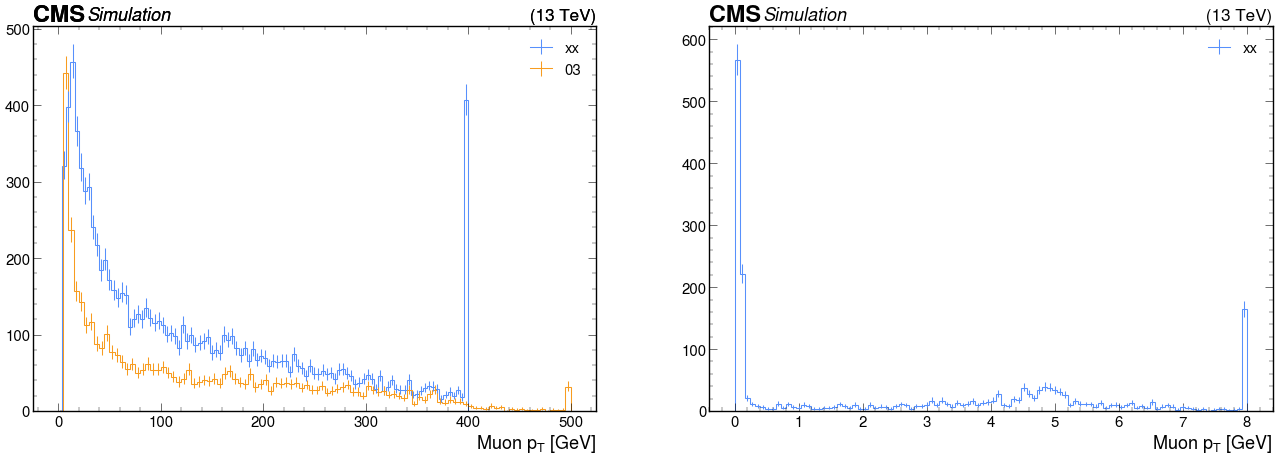

In [16]:
npl = 2
ss2 = sig2mu[0]

plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1, 2,1)
# utilities.plot(out2mu[ss2]["hists"]["lj00_invmass"][ch1, :], label = "00")
# utilities.plot(out2mu[ss2]["hists"]["lj01_invmass"][ch1, :], label = "01")
# utilities.plot(out2mu[ss2]["hists"]["lj02_invmass"][ch1, :], label = "02")
# utilities.plot(out2mu[ss2]["hists"]["lj03_invmass"][ch1, :], label = "03")
# utilities.plot(out2mu[ss2]["hists"]["lj12_invmass"][ch1, :], label = "00")
# utilities.plot(out2mu[ss2]["hists"]["lj13_invmass"][ch1, :], label = "01")
# utilities.plot(out2mu[ss2]["hists"]["lj23_invmass"][ch1, :], label = "02")
utilities.plot(out2mu[ss2]["hists"]["muon_in_lj_pt"][ch3, :], label = "xx")
utilities.plot(out2mu[ss2]["hists"]["muon_pt"][ch3, :], label = "03")
plt.legend()

# plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1, 2,2)
utilities.plot(out2mu[ss2]["hists"]["muon_in_lj_mass"][ch2, :], label = "xx")
# utilities.plot(out2mu[ss2]["hists"]["ljm_invmass"][ch1, :], label = ch1)
# utilities.plot(out2mu[ss2]["hists"]["ljm2_invmass"][ch3, :], label = ch3)
plt.legend()

In [9]:
ovjqat

NameError: name 'ovjqat' is not defined

In [ ]:
#process 4mu
# fileset4mu = utilities.make_fileset(sig4mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_4mu_v10.yaml")
# out4mu = runner.run(fileset4mu, treename="Events", processor_instance=p)
# out4mu = out4mu["out"]
# coffea.util.save(out4mu, "outputs/bkg_" + vr + "_4mu.coffea")

In [ ]:
# htplot = ["mulj1Mass"]
# out2 = coffea.util.load("outputs/bkg_28_2mu.coffea")
# out4 = coffea.util.load("outputs/bkg_28_4mu.coffea")

# output = {**out2, **out4}

cha = ch2
npl = 2
# ss2 = sig2mu[0]
# ss4 = sig4mu[0]
mzd = ["0.25", "1.2", "5.0"]
###################
#### 2mu  ########
###################
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,1)
for im, ss2 in enumerate(sig2mu):
    utilities.plot(output[ss2]["hists"]["lj0_mass"][cha, :], label = f"Leading {mzd[im]}")
    utilities.plot(output[ss2]["hists"]["lj1_mass"][cha, :], label = f"subLeading {mzd[im]}")
plt.title("2mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)

plt.subplot(1,2,2)
for im, ss2 in enumerate(sig2mu):
    utilities.plot(output[ss2]["hists"]["lj_mass_diff"][cha, :], label = mzd[im])
plt.title("2mu")
plt.yscale("log")
plt.legend(title=r"$Z_D$ mass [GeV]", alignment="left", loc=0)

###################
#### 4mu  ########
###################

cha = ch1
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,1)
for im, ss4 in enumerate(sig4mu):
    utilities.plot(output[ss4]["hists"]["lj0_mass"][cha, :], label = f"Leading {mzd[im]}")
    utilities.plot(output[ss4]["hists"]["lj1_mass"][cha, :], label = f"subleading {mzd[im]}")
plt.title("4mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)

plt.subplot(1,2,2)
for im, ss4 in enumerate(sig4mu):
    utilities.plot(output[ss4]["hists"]["lj_mass_diff"][cha, :], label = mzd[im])
plt.title("4mu")
plt.yscale("log")
plt.legend(title=r"$Z_D$ mass [GeV]", alignment="left", loc=0)

In [ ]:
# htplot = ["mulj1Mass"]
out2 = coffea.util.load("outputs/bkg_28_2mu.coffea")
out4 = coffea.util.load("outputs/bkg_28_4mu.coffea")

output = {**out2, **out4}

cha = ch2
npl = 2
# ss2 = sig2mu[0]
# ss4 = sig4mu[0]
mzd = ["0.25", "1.2", "5.0"]
###################
#### 2mu  ########
###################
plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,1)
for im, ss2 in enumerate(sig2mu):
    utilities.plot(output[ss2]["hists"]["lj0_mass"][cha, :], label = f"Leading {mzd[im]}")
    utilities.plot(output[ss2]["hists"]["lj1_mass"][cha, :], label = f"subLeading {mzd[im]}")
plt.title("2mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)



###################
#### 4mu  ########
###################

cha = ch1
# plt.subplots(1, npl, figsize=(npl*16, 10))
plt.subplot(1,2,2)
for im, ss4 in enumerate(sig4mu):
    utilities.plot(output[ss4]["hists"]["lj0_mass"][cha, :], label = f"Leading {mzd[im]}")
    utilities.plot(output[ss4]["hists"]["lj1_mass"][cha, :], label = f"subleading {mzd[im]}")
plt.title("4mu")
plt.yscale("log")
plt.legend(title=r"lepton jet - $Z_D$ mass [GeV] ", alignment="left", loc=0)
plt.savefig(f"clean_plots/ljmass.png", bbox_inches="tight", dpi=300)

In [ ]:
# process DYJ
# filesetdyj = utilities.make_fileset(bkgdyj, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
# outdyj     = runner.run(filesetdyj, treename="Events", processor_instance=p)
# outdyj     = outdyj["out"]

In [ ]:
# Process ttj
filesetttj = utilities.make_fileset(bkgttj, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outttj     = runner.run(filesetttj, treename="Events", processor_instance=p)
outttj     = outttj["out"]
coffea.util.save(outttj, "outputs/bkg_" + vr + "_ttj.coffea")

In [ ]:
# process qcd
# filesetqcd    = utilities.make_fileset(bkgqcd, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
# outqcd        = runner.run(filesetqcd, treename="Events", processor_instance=p)
# outqcd        = outqcd["out"]

In [ ]:
# process ocd
filesetocd    = utilities.make_fileset(bkgocd, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outocd        = runner.run(filesetocd, treename="Events", processor_instance=p)
outocd        = outocd["out"]
coffea.util.save(outocd, "outputs/bkg_" + vr + "_ocd.coffea")

In [ ]:
# outall = {
#     # **out2mu, 
#     **out4mu,
#     # **outdyj,
#     # **outttj,
#     # **outqcd, 
#     # **outocd,
# }

# File 28
## test ljmass difference

In [ ]:
# htplot = ["mulj1Mass"]
output = coffea.util.load("outputs/bkg_28_4mu.coffea")
outocd = coffea.util.load("outputs/bkg_28_ocd.coffea")
cha = ch3

plt.subplots(1, 2, figsize=(32, 10))
plt.subplot(1,2,1)
# for ij, sss in enumerate(mxx2):
# utilities.plot(output[sig4mu[0]]["hists"]["mulj1Mass"][cha, :], label = "Lead")
# utilities.plot(output[sig4mu[0]]["hists"]["mulj2Mass"][cha, :], label = "sLead")
# utilities.plot(output[sig4mu[0]]["hists"]["lje_invmass"][cha, :], label = "Ele")
utilities.plot(output[sig4mu[0]]["hists"]["ljm_invmass"][cha, :], label = "Muon")
utilities.plot(output[sig4mu[0]]["hists"]["ljm_invmass"][cha, :], label = "Muon")

plt.title("Muon Lj mass")
plt.ylabel("Events")
plt.yscale("log")
plt.legend(title=r"$\mu$-type", alignment="left", loc=0)

plt.subplot(1,2,2)
utilities.plot(output[sig4mu[0]]["hists"]["muljs_Massdiff"][cha, :], label = r"sig")   #r"|m_{lj1} - m_{lj2}|")
plt.title("Muon Ljs mass diff")
plt.ylabel("Events")
plt.yscale("log")
plt.legend(title=r"$\mu$-type", alignment="left", loc=0)

# plt.savefig(f"clean_plots/fin_28_ljmass_4mu.pdf", bbox_inches="tight", dpi=300)

# test mass cut on invmass BS

In [ ]:

# htplot = ["mulj1Mass"]
output = coffea.util.load("outputs/bkg_28_4mu.coffea")
outocd = coffea.util.load("outputs/bkg_28_ocd.coffea")
cha = [ch1, ch3, ch4, ch5]
chaname = ["base", r"$4\mu$", r"mass diff", r"$m_{jj}>150$"]
npl = 2

plt.subplots(1, npl, figsize=(16*npl, 10))
plt.subplot(1,2,1)
for ij, ch in enumerate(cha):
    utilities.plot(output[sig4mu[0]]["hists"]["lj_lj_invmass"][ch, :], label = chaname[ij])
    plt.title("LJ_LJ inv mass")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection", alignment="left", loc=1)

# OCD = merge_samples(outocd, bkgocd, "lj_lj_invmass", ch)

plt.subplot(1,2,2)
for ij, ch in enumerate(cha):
    OCD = merge_samples(outocd, bkgocd, "lj_lj_invmass", ch)
    utilities.plot(OCD, label=chaname[ij])
    # TTJ = merge_samples(outttj, bkgttj, "lj_lj_invmass", ch)
    # utilities.plot(OCD, label=ch,)
    # utilities.plot(output[sig4mu[0]]["hists"]["lj_lj_invmass"][ch5, :], label = ch)
    plt.title("LJ_LJ inv mass")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection", alignment="left", loc=0)

# plt.savefig(f"clean_plots/fin_{26}_muonRes_2mu.pdf", bbox_inches="tight", dpi=300)

In [ ]:
outocd

In [ ]:
ht = "lj_lj_invmass"
cha2name = ["Base", "Iso", "Disp", r"2mu2e", r"$\Delta\Phi > 2$"]
cha2 = [ch1, ch2, ch3, ch5,]

for ic, ch in enumerate(cha2):
    
    fig, ax = plt.subplots(figsize=(16,10))
    
    # DYJ = merge_samples(output, bkgdyj, ht, ch)
    QCD = merge_samples(output, bkgocd, ht, ch)
    TTJ = merge_samples(output, bkgttj, ht, ch)
    
    # Backgrounds stacked
    hep.histplot([QCD, TTJ],     stack=True,     histtype="fill",     color=["green", "red"],     label=["QCD", "TTJ"],     ax=ax,)
    
    # Signal overlaid
    colmx=["black", "darkviolet", "navy", "magenta", "darkorange", "darkblue"]
    labmx=[r"$2\mu2e: m_{xx}=200$", r"$2\mu2e: m_{xx}=500$", r"$2\mu2e: m_{xx}=800$", r"$2\mu2e: m_{xx}=1000$"]
    hep.histplot(output[sig4mu[0]]["hists"]["lj_lj_invmass"][ch, :], 
                     color=colmx[ix], 
                     label=labmx[ix], 
                     histtype="step", 
                     linewidth=3, 
                     ax=ax
                    )
    # for ix, sss in enumerate(mxx2):
    #     hep.histplot(output[sss]["hists"][ht][ch1, ::2j], 
    #                  color=colmx[ix], 
    #                  label=labmx[ix], 
    #                  histtype="step", 
    #                  linewidth=3, 
    #                  ax=ax
    #                 )
    hep.cms.label(data=False,
    lumi=None,
    com=13,
    ax=ax,
    )
    ax.set_ylim(1, 1000000)
    # ax.yscale(1,10000)
    ax.set_yscale("log")
    ax.legend(title="Process", ncol=2)
    plt.title(f"selection: {cha2name[ic]}")
    # plt.show()
    # plt.savefig(f"clean_plots/fin_bkg_stack_{vr}_{ht}_{cha2name[ic]}_mxx.pdf", bbox_inches="tight", dpi=300)

In [ ]:
plt.subplots(1, 1, figsize=(16, 10))
plt.subplot(1,2,1)
utilities.plot(outall[sig4mu[0]]["hists"]["lj_lj_invmass"][ch2, :], label = sig4mu[0])
# utilities.plot(outall[sig4mu[0]]["hists"]["lj_lj_invmass"][ch1, :], label = "lj2")
utilities.plot(outall[bkgdyj[0]]["hists"]["lj_lj_invmass"][ch2, :], label = "dyj")
utilities.plot(outall[bkgttj[0]]["hists"]["lj_lj_invmass"][ch2, :], label = "ttj")

plt.yscale("log")
plt.title("-")
plt.legend()

plt.subplot(1,2,2)
utilities.plot(outall[sig4mu[0]]["hists"]["lj_lj_invmass"][ch3, :], label = sig4mu[0])
# utilities.plot(outall[sig4mu[0]]["hists"]["lj_lj_invmass"][ch1, :], label = "lj2")
utilities.plot(outall[bkgdyj[0]]["hists"]["lj_lj_invmass"][ch3, :], label = "dyj")
utilities.plot(outall[bkgttj[0]]["hists"]["lj_lj_invmass"][ch3, :], label = "ttj")

plt.yscale("log")
plt.title("-")
plt.legend()

In [ ]:
plt.subplots(1, 2, figsize=(32, 10))
plt.subplot(1,2,1)
utilities.plot(out4mu[sig4mu[0]]["hists"]["mulj1Mass"][ch1, :], label = "lj1")
utilities.plot(out4mu[sig4mu[0]]["hists"]["mulj2Mass"][ch1, :], label = "lj2")
plt.yscale("log")
plt.title(sig4mu[0])
plt.legend()

plt.subplot(1, 2, 2)
utilities.plot(out4mu[sig4mu[0]]["hists"]["mulj1Mass"][ch2, :], label = "lj1")
utilities.plot(out4mu[sig4mu[0]]["hists"]["mulj2Mass"][ch2, :], label = "lj2")
plt.yscale("log")
plt.title(sig4mu[0])
plt.legend()
# plt.savefig(f"clean_plots/fin_mass.pdf", bbox_inches="tight", dpi=300)

In [ ]:
plt.subplots(1, 2, figsize=(32, 10))
plt.subplot(1,2,1)
utilities.plot(out4mu[sig4mu[0]]["hists"]["muljs_Massdiff"][ch1, ::2j], label = "No cut")
plt.yscale("log")
plt.title(sig4mu[0])
plt.legend()

plt.subplot(1, 2, 2)
utilities.plot(out4mu[sig4mu[0]]["hists"]["muljs_Massdiff"][ch2, ::2j], label = r"$\Delta(m1, m2) < 0.1$")
plt.yscale("log")
plt.title(sig4mu[0])
plt.legend()
# plt.savefig(f"clean_plots/fin_mass_diff.pdf", bbox_inches="tight", dpi=300)

In [ ]:
plt.subplots(1, 1, figsize=(16, 10))
# plt.subplot(1,2,1)
utilities.plot(out4mu[sig4mu[0]]["hists"]["lj_lj_invmass"][ch1, ::2j], label = "No cut")
utilities.plot(out4mu[sig4mu[0]]["hists"]["lj_lj_invmass"][ch2, ::2j], label = "4mu")
utilities.plot(out4mu[sig4mu[0]]["hists"]["lj_lj_invmass"][ch3, ::2j], label = r"$\Delta(m1, m2) < 0.1$")
plt.yscale("log")
plt.title(sig4mu[0])
plt.legend()

# plt.subplots(1, 2, figsize=(32, 10))
# plt.subplot(1,2,1)
# utilities.plot(out4mu[sig4mu[0]]["hists"]["lj_lj_invmass"][ch2, ::2j], label = "No cut")
# plt.yscale("log")
# plt.title(sig4mu[0])
# plt.legend()

# plt.subplot(1, 2, 2)
# utilities.plot(out4mu[sig4mu[0]]["hists"]["muljs_Massdiff"][ch2, ::2j], label = r"$\Delta(m1, m2) < 0.1$")
# plt.yscale("log")
# plt.title(sig4mu[0])
# plt.legend()
# plt.savefig(f"clean_plots/fin_mass_diff.pdf", bbox_inches="tight", dpi=300)

In [ ]:
plt.subplots(1, 1, figsize=(16, 10))
# utilities.plot(out2mu[sig2mu[0]]["hists"]["muon_muon_dR"][ch1, ::3j], label = "dR")
utilities.plot(out2mu[sig2mu[0]]["hists"]["muon_muon_dR2"][ch1, ::3j], label = "dR2")

In [ ]:
plt.subplots(1, 1, figsize=(16, 10))
# utilities.plot(out2mu[sig2mu[0]]["hists"]["muon_muon_dR"][ch1, ::3j], label = "dR")
utilities.plot(out2mu[sig2mu[0]]["hists"]["muon_genMu_matched_dR"][ch1, ::3j], label = "dR2")

In [ ]:
plt.subplots(1, 1, figsize=(16, 10))
utilities.plot(out2mu[sig2mu[0]]["hists"]["muon_pt_resolution"][ch1, :], label = "PF")
utilities.plot(out2mu[sig2mu[0]]["hists"]["dsaMuon_pt_resolution"][ch1, :], label = "DSA")
plt.legend()

In [ ]:
h = out2mu[sig2mu[0]]["hists"]["lj_eta_phi"]
# print(h.axes)

plt.subplots(1, 1, figsize=(16, 10))
utilities.plot(out2mu[sig2mu[0]]["hists"]["lj_eta_phi"][channels[0], ::2j, :].project("ljs_eta"), density=False)

plt.subplots(1, 1, figsize=(16, 10))
utilities.plot(out2mu[sig2mu[0]]["hists"]["lj_eta_phi"][channels[0], ::2j, :].project("ljs_phi"), density=False)